In [1]:
%cd /Data/gfi/users/rogui7909/code/predict_rain_norway/clean_stuff

/felles_gfi/felles_gfi_users/rogui7909/code/predict_rain_norway/clean_stuff


In [8]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import numpy as np
import torch # long
from lightning.pytorch import loggers, seed_everything
import xarray as xr
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from lightning.pytorch import  seed_everything
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)


Seed set to 42


Running imports...


42

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_backtoclassif", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Scientific_software/software/Anaconda3/2024.06-1/lib/python3.12/site-packages/pydantic/main.py:308: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


In [17]:
from src.data import MyDataLoader
from src.lightning import ExtremeRainPredictor, AttributableTrainer

In [ ]:
loader = MyDataLoader(wandb_logger)


/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/core/indexing.py:1679: PerformanceWarning: Slicing with an out-of-order index is generating 1370 times more chunks
  return self.array[key]


12 2


In [24]:
callbacks=[EarlyStopping(monitor="val/loss", mode="min")]
trainer = AttributableTrainer(limit_train_batches=100, 
                              max_epochs=wandb_logger.experiment.config['num_epochs'], 
                              logger=wandb_logger, 
                              log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                              callbacks=callbacks, deterministic=True,
                              accelerator="gpu", devices=1,)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [28]:
X = loader.train_loader.dataset[0][0][:1]
X.shape

torch.Size([1, 2, 32, 128])

In [34]:
NN = ConvLayerStride1_ConvLayerStride2(input_channels = 2, 
                             output_channels=32)
               
NN(X).shape

RuntimeError: Given groups=1, weight of size [32, 32, 2, 2], expected input[1, 2, 32, 128] to have 32 channels, but got 2 channels instead

In [ ]:
import torch.nn as nn

class ConvLayerStride1MaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1MaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.maxpool(output)
        output = self.activation_function(output)
        return output


class ConvLayerStride1_ConvLayerStride2(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride1_ConvLayerStride2, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer1 = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=1, padding=(size_conv_kernel-1)//2)
        self.conv_layer2 = nn.Conv2d(self.output_channels, 
                                    self.output_channels, 
                                    kernel_size=2, 
                                    stride=2, padding=(size_conv_kernel-1)//2)
        
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer1(x)
        output = self.conv_layer2(output)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output
    
class ConvLayerStride2NoMaxPool(nn.Module):
    def __init__(self, 
                 input_channels, 
                 output_channels,
                 activation_function=nn.ReLU(),
                 size_conv_kernel=3
                 ):
        super(ConvLayerStride2NoMaxPool, self).__init__()
        self.input_channels = input_channels
        self.output_channels = output_channels
        self.activation_function = activation_function
        self.conv_layer = nn.Conv2d(self.input_channels, 
                                    self.output_channels, 
                                    kernel_size=size_conv_kernel, 
                                    stride=2, padding=(size_conv_kernel-1)//2)
        self.bn2 = nn.BatchNorm2d(output_channels)

    def forward(self, x):
        output = self.conv_layer(x)
        output = self.bn2(output)
        output = self.activation_function(output)
        return output
        
#         # x shape: (batch_size, seq_length, channels, height, width)
#         # Apply CNN to extract spatial features
#         self.conv_layer1 = nn.Sequential(
# #                                      nn.Conv2d(input_channels, 
# #                                      out_channels_conv1, 
# #                                      kernel_size=size_conv_kernel, 
# #                                      stride=1, padding=(size_conv_kernel-1)//2),
# #                             nn.MaxPool2d(kernel_size=2, stride=2),
# #                             nn.ReLU())
#         batch_size,  channels, height, width = x.size()
#         print(self.linear_size)
#         if self.number_conv_layers>0:
#             cnn_out = self.cnn(x)
#         else:
#             cnn_out = x
#         cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
#         output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
#         output = self.fc2(output)
#         output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
#         output = torch.sigmoid(output) 
#         X1 = output[:,:,0]
#         X2 = output[:,:,1]
#         P_norain = X1 
#         P_rain = (1-X1)*(1-X2)
#         P_extreme = (1-X1)*X2
#         output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
#         return output.view(-1, self.num_timesteps*self.classes_per_timestep)
        # print(output.shape)



        
# class CNN(nn.Module):
#     def __init__(self, 
#                  input_channels, 
#                  image_size, 
#                  num_timesteps,
#                  number_conv_layers=4,
#                  size_conv_kernel=3,
#                  out_channels_conv1=12, 
#                  out_channel_factor_increase_per_layer = 2,
#                  ):
#         super(CNN_Model_2, self).__init__()
        
#         # CNN layers to extract spatial features
#         # self.sigmoid = sigmoid
#         # self.softmax = softmax
#         self.num_timesteps = num_timesteps
#         self.classes_per_timestep = 3
#         self.num_classes = self.num_timesteps*(self.classes_per_timestep-1)
#         self.number_conv_layers = number_conv_layers
#         self.conv_layer1 = nn.Sequential(
#                                      nn.Conv2d(input_channels, 
#                                      out_channels_conv1, 
#                                      kernel_size=size_conv_kernel, 
#                                      stride=1, padding=(size_conv_kernel-1)//2),
#                             nn.MaxPool2d(kernel_size=2, stride=2),
#                             nn.ReLU())
#         self.conv_layer2 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer3 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer**2, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer4 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**2, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer**3, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer5 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**3, 
#                                           out_channels_conv1*out_channel_factor_increase_per_layer**4, 
#                                           kernel_size=size_conv_kernel, 
#                                           stride=1, padding=(size_conv_kernel-1)//2),
#                                 nn.MaxPool2d(kernel_size=2, stride=2),
#                                 nn.ReLU())
#         self.conv_layer6 = nn.Sequential(
#                                 nn.Conv2d(out_channels_conv1*out_channel_factor_increase_per_layer**4, 
#                                             out_channels_conv1*out_channel_factor_increase_per_layer**5, 
#                                             kernel_size=size_conv_kernel, 
#                                             stride=1, padding=1),
#                                 nn.MaxPool2d(kernel_size=(1,2), stride=2),
#                                 nn.ReLU())
        
#         if number_conv_layers == 1:
#             self.cnn = nn.Sequential(self.conv_layer1)
#         elif number_conv_layers == 2:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2)
#         elif number_conv_layers == 3:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3)
#         elif number_conv_layers == 4:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4)
#         elif number_conv_layers == 5:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5)
#         elif number_conv_layers == 6:
#             self.cnn = nn.Sequential(self.conv_layer1, self.conv_layer2, self.conv_layer3, self.conv_layer4, self.conv_layer5, self.conv_layer6)
        
#         max_pools = 4**(number_conv_layers)
#         self.output_cnn_channels  = out_channels_conv1*out_channel_factor_increase_per_layer**(number_conv_layers-1)
#         if self.number_conv_layers == 0:
#             self.linear_size = image_size 
#         else:
#             self.linear_size = image_size * self.output_cnn_channels // max_pools 
#         if self.number_conv_layers == 6:
#             self.linear_size = self.linear_size*2
#         if self.number_conv_layers == 0:
#             self.linear_size = image_size*2 
#         self.fc1 = nn.Linear(self.linear_size, 512)
#         self.fc2 = nn.Linear(512, self.num_classes)
    
#     def forward(self, x):
#         # x shape: (batch_size, seq_length, channels, height, width)
#         # Apply CNN to extract spatial features
#         batch_size,  channels, height, width = x.size()
#         print(self.linear_size)
#         if self.number_conv_layers>0:
#             cnn_out = self.cnn(x)
#         else:
#             cnn_out = x
#         cnn_out = cnn_out.view(batch_size, -1)  # Shape: (batch_size, seq_length, features)
#         output = self.fc1(cnn_out)  # Shape: (batch_size, output_size)
#         output = self.fc2(output)
#         output = output.view(-1, self.num_timesteps, self.classes_per_timestep-1)
#         output = torch.sigmoid(output) 
#         X1 = output[:,:,0]
#         X2 = output[:,:,1]
#         P_norain = X1 
#         P_rain = (1-X1)*(1-X2)
#         P_extreme = (1-X1)*X2
#         output = torch.stack([P_norain, P_rain, P_extreme], dim=2)
#         return output.view(-1, self.num_timesteps*self.classes_per_timestep)
#         # print(output.shape)
        



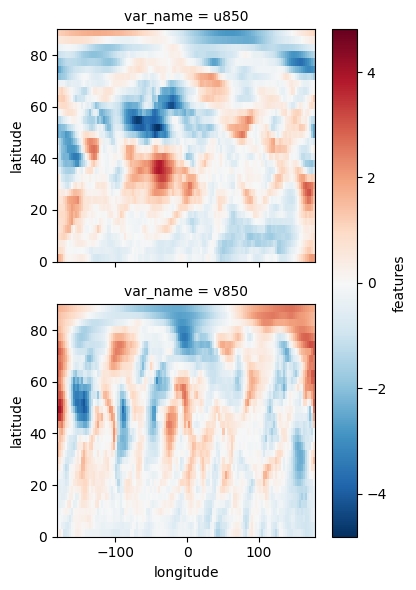

In [23]:
loader.ds_train.sel(time='1969-01-10').features.plot( row='var_name')

In [12]:
wandb.finish()

In [95]:
ds = loader.get_ds_train()

/Data/gfi/users/rogui7909/virtual_envs/postdoc/lib/python3.12/site-packages/xarray/core/indexing.py:1679: PerformanceWarning: Slicing with an out-of-order index is generating 1377 times more chunks
  return self.array[key]


In [ ]:
import dask


In [136]:
ds_out

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 151844, var_name: 2, latitude: 32, longitude: 128,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 1MB 1967-02-01 1984-02-25 ... 1975-01-10
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float64 10GB dask.array<chunksize=(1, 1, 8, 32), meta=np.ndarray>
    targets    (time, timestep) int64 5MB 0 1 2 1 1 0 1 1 1 ... 1 1 1 2 1 1 1 2
    rain       (time, timestep) float32 2MB 0.7499 9.335 25.07 ... 13.92 25.83

In [142]:
shuffled_time = np.arange(ds_out.time.size)
np.random.shuffle(shuffled_time)
ds_out.isel(time=shuffled_time)

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 151844, var_name: 2, latitude: 32, longitude: 128,
                timestep: 4)
Coordinates:
  * longitude  (longitude) float64 1kB -180.0 -177.2 -174.4 ... 174.4 177.2
  * var_name   (var_name) object 16B 'u850' 'v850'
  * time       (time) datetime64[ns] 1MB 1996-08-02 1994-01-08 ... 1986-04-07
  * latitude   (latitude) float64 256B 1.406 4.219 7.031 ... 82.97 85.78 88.59
    mask_id    int64 8B 14
    quantile   float64 8B 0.9
Dimensions without coordinates: timestep
Data variables:
    features   (time, var_name, latitude, longitude) float64 10GB dask.array<chunksize=(1, 1, 8, 32), meta=np.ndarray>
    targets    (time, timestep) int64 5MB 1 1 1 0 1 0 0 0 1 ... 1 1 1 1 0 0 0 0
    rain       (time, timestep) float32 2MB 17.87 5.234 4.536 ... 0.2446 0.1134